In [1]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import copy



/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
model = "word_task_v09_cue_loc_task"

analysis_dir = Path(f"binaural_unit_activations/{model}")

anova_results = list(analysis_dir.glob("*.npz"))


h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 

target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

48
12
Optimal number of bins: 9


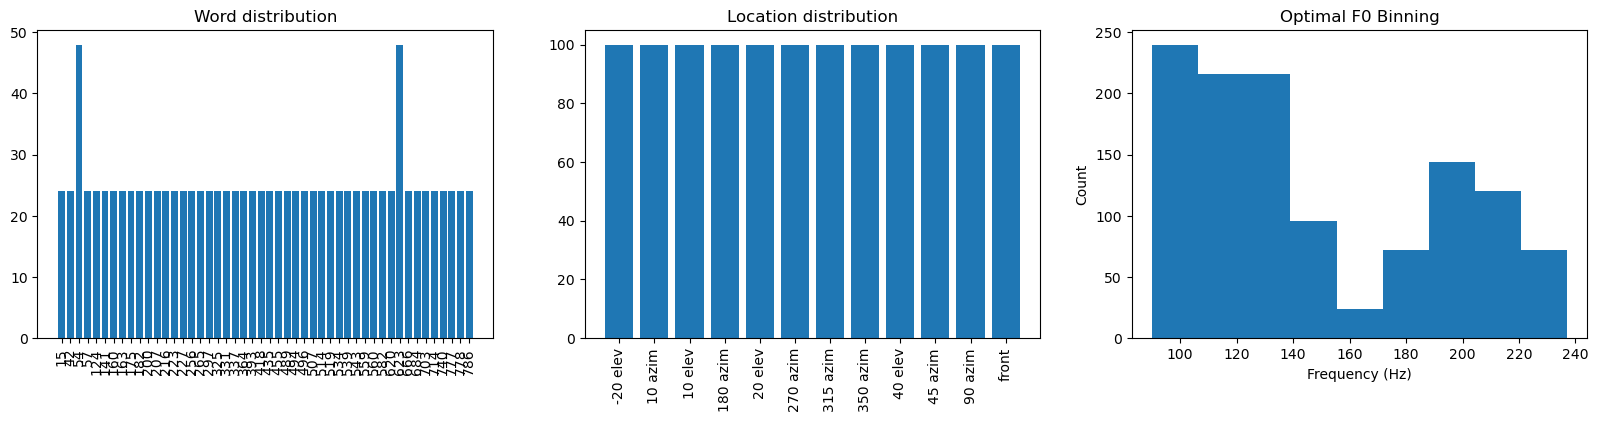

In [3]:
plt.figure(figsize=(20, 4))
plt.subplot(131)
words, count = np.unique(h5['target_word_int'][:], return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(words))
plt.xticks(np.arange(len(count)), words.astype('int'), rotation=90);
plt.title('Word distribution')

### get binning for location classes 

#  
unique_locations = np.unique(target_locs, axis=0).astype(int)
# print(unique_locations)
loc_list = np.zeros(len(target_locs), dtype=object)
for loc in unique_locations:
    loc_ixs = np.where(np.all(target_locs == loc, axis=1))[0]
    azim, elev = loc
    if elev == 0 and azim == 0:
        loc_list[loc_ixs] = 'front'
    elif elev == 0:
        loc_list[loc_ixs] = f"{azim} azim"
    elif azim == 0:
        loc_list[loc_ixs] = f"{elev} elev"

plt.subplot(132)
locs, count = np.unique(loc_list, return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(locs))
plt.xticks(np.arange(len(locs)), locs, rotation=90);
plt.title('Location distribution')


### get binning for pitch classes 
def optimal_bin_count(data, min_bins=1, max_bins=50):
    # Calculate the Freedman-Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)
    bin_width = max(bin_width, 1e-5)  # Ensure bin width is not zero

    # Calculate the range of bin counts to test
    data_range = np.ptp(data)
    min_bins = max(min_bins, int(np.ceil(data_range / bin_width)))
    max_bins = min(max_bins, int(np.floor(data_range / bin_width)))

    best_bin_count = min_bins
    best_variance = float('inf')

    # Iterate over the range of bin counts
    for bins in range(min_bins, max_bins + 1):
        counts, _ = np.histogram(data, bins=bins)
        variance = np.var(counts)
        if variance < best_variance:
            best_variance = variance
            best_bin_count = bins

    return best_bin_count

plt.subplot(133)
# Example usage with target_f0s data
# target_f0s = np.random.rand(100) * 100  # Replace with your actual data
optimal_bins = optimal_bin_count(target_f0s)
print(f"Optimal number of bins: {optimal_bins}")

# Plot the histogram with the optimal number of bins
plt.hist(target_f0s, bins=optimal_bins)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
plt.title('Optimal F0 Binning')
plt.show()




In [4]:
from sklearn.metrics.pairwise import cosine_similarity


## Get list of cue activation layers
wanted_layers = [layer for layer in h5.keys() if 'relu' in layer and 'cue' in layer]

cor_records = []
for layer in wanted_layers:
    for loc_i in unique_locations:
        for loc_j in unique_locations:
            loc_i_ixs = np.where(np.all(target_locs == loc_i, axis=1))[0]
            loc_j_ixs = np.where(np.all(target_locs == loc_j, axis=1))[0]
            loc_i_acts = h5[layer][loc_i_ixs]
            loc_j_acts = h5[layer][loc_j_ixs]
            ## get cor between each element of loc_i_acts and loc_j_acts
            cor = np.mean([stats.pearsonr(i_act, j_act)[0] for i_act, j_act in zip(loc_i_acts, loc_j_acts)])
            cos_sim = np.diag(cosine_similarity(loc_i_acts, loc_j_acts)).mean()
            cor_records.append({'correlation': cor, 'cos_sim':cos_sim, 'layer': layer, 'loc_i': loc_i, 'loc_j': loc_j})




In [5]:
### Similarity df 

sim_df = pd.DataFrame(cor_records)
loc_i = np.stack(sim_df['loc_i'].values)
loc_j = np.stack(sim_df['loc_j'].values)

# wrap azimuth 
# loc_i[loc_i[:, 0] > 180, 0] = loc_i[loc_i[:, 0] > 180, 0] - 360
# loc_j[loc_j[:, 0] > 180, 0] = loc_j[loc_j[:, 0] > 180, 0] - 360
# loc_i = np.minimum(loc_i, np.abs(181 - loc_i))
# loc_j = np.minimum(loc_j, np.abs(181 - loc_j))

sim_df['elevation_delta'] = np.abs(loc_i[:, 1] - loc_j[:, 1])
sim_df['azimuth_delta'] = np.abs(loc_i[:, 0] - loc_j[:, 0])
sim_df.loc[sim_df['azimuth_delta'] > 180, 'azimuth_delta'] =  sim_df.loc[sim_df['azimuth_delta'] > 180, 'azimuth_delta'] - 180 

# wrap around azimuth

In [6]:
sim_df['azimuth_delta'].unique()

array([  0,  10,  45,  90, 180, 135, 170,  35,  80, 125, 160])

In [11]:
sim_df[sim_df.azimuth_delta == 0].layer.unique()

array(['conv_block_0_relu_cue', 'conv_block_1_relu_cue',
       'conv_block_2_relu_cue', 'conv_block_3_relu_cue',
       'conv_block_4_relu_cue', 'conv_block_5_relu_cue',
       'conv_block_6_relu_cue'], dtype=object)

In [14]:
sim_df[sim_df.elevation_delta == 0].layer.unique()

array(['conv_block_0_relu_cue', 'conv_block_1_relu_cue',
       'conv_block_2_relu_cue', 'conv_block_3_relu_cue',
       'conv_block_4_relu_cue', 'conv_block_5_relu_cue',
       'conv_block_6_relu_cue'], dtype=object)

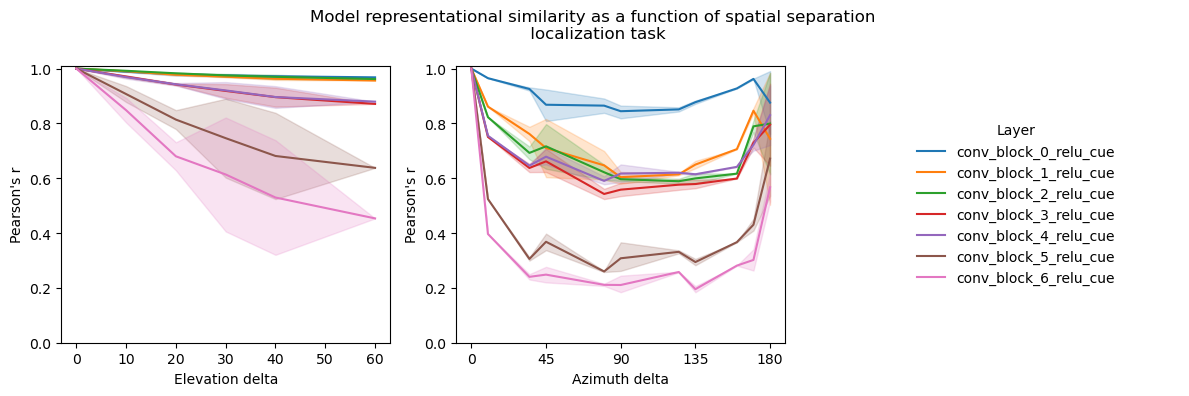

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), )
sns.lineplot(data=sim_df[sim_df.azimuth_delta == 0], x='elevation_delta', y='correlation', hue='layer', ax=axs[0])
sns.lineplot(data=sim_df[sim_df.elevation_delta == 0], x='azimuth_delta', y='correlation', hue='layer', ax=axs[1])
# put common legend on pannel 3

axs[0].legend().remove()
axs[1].legend().remove()

axs[0].set_xlabel(f"Elevation delta")
axs[1].set_xlabel(f"Azimuth delta")
axs[0].set_xlabel(f"Elevation delta")
axs[0].set_ylim(0, 1.01)
axs[1].set_ylim(0, 1.01)

axs[1].set_xticks([0, 45, 90, 135, 180])

for ax in axs:
    ax.set_ylabel("Pearson's r")

# axs[0,-1].axis('off')
handles, labels = axs[1].get_legend_handles_labels()

axs[2].axis('off')
legend = axs[2].legend(handles, labels,
                frameon=False,
                title='Layer',
                loc='center'
                )
plt.suptitle('Model representational similarity as a function of spatial separation \n localization task')
plt.tight_layout()



In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# cos sim manually computed (a * b) / (||a|| * ||b||) == (a / ||a||) * (b / ||b||)
i_acts_norm = loc_i_acts  / np.linalg.norm(loc_i_acts,ord=2,axis=1,keepdims=True)
j_acts_norm = loc_j_acts  / np.linalg.norm(loc_j_acts,ord=2,axis=1,keepdims=True)

cos_sims = np.diag(np.matmul(i_acts_norm, j_acts_norm.T))

cos_sims_sk = np.diag(cosine_similarity(loc_i_acts, loc_j_acts))


100

In [76]:
np.linalg.norm(loc_i_acts,ord=2,axis=1,keepdims=True).shape

(100, 1)

In [7]:
results_dict = {}

for result in anova_results:
    layer_name = "_".join(result.stem.split("_")[:3])
    print(layer_name)
    results = np.load(result)
    results_dict[layer_name] = {"prop_var_exp": results['prop_var_per_unit'], 'ssq_per_unit':results['ssq_per_unit']}

category_labels = results['category_labels']

hann_pool_0
hann_pool_1
hann_pool_2
hann_pool_3
hann_pool_4
hann_pool_5
hann_pool_6


In [8]:
# n_to_plot = len(results_dict)

# fig, ax = plt.subplots(1, n_to_plot, figsize=(20, 4))

# n_cats = len(category_labels) # will be for location, f0, interaction

# for layer_ix, (layer_name, results) in enumerate(results_dict.items()):
#     results_to_plot_prop = results['prop_var_exp']
#     n_units = results_to_plot_prop.shape[0]
#     bottom = np.zeros(n_units)

#     for cat_ix in range(n_cats):
#         # sns.barplot(x=np.arange(n_units), y=results_to_plot_prop[:, cat_ix],  color=f"C{cat_ix}", ax=ax[layer_ix], orient='h', label=category_labels[cat_ix])
#         ax[layer_ix].barh(np.arange(n_units), results_to_plot_prop[:, cat_ix],  color=f"C{cat_ix}", label=category_labels[cat_ix], alpha=0.9, left=bottom)
#         bottom += results_to_plot_prop[:, cat_ix]
        
#     ax[layer_ix].set_xlabel('Prop. Variance Explained')
#     ax[layer_ix].set_ylabel('Unit')
#     ax[layer_ix].set_title(layer_name)
#     ax[layer_ix].set_ylim(0, n_units)
#     ax[layer_ix].set_xlim(0, 1)

#     if layer_ix < n_to_plot-1:
#         # remove legend for all but last plot
#         ax[layer_ix].legend().set_visible(False)
#     else:
#         ax[layer_ix].legend(loc='upper left', bbox_to_anchor=(1, 1))

#     # move legend outside of plot
# sns.despine(left=True, bottom=True)


# plt.tight_layout()



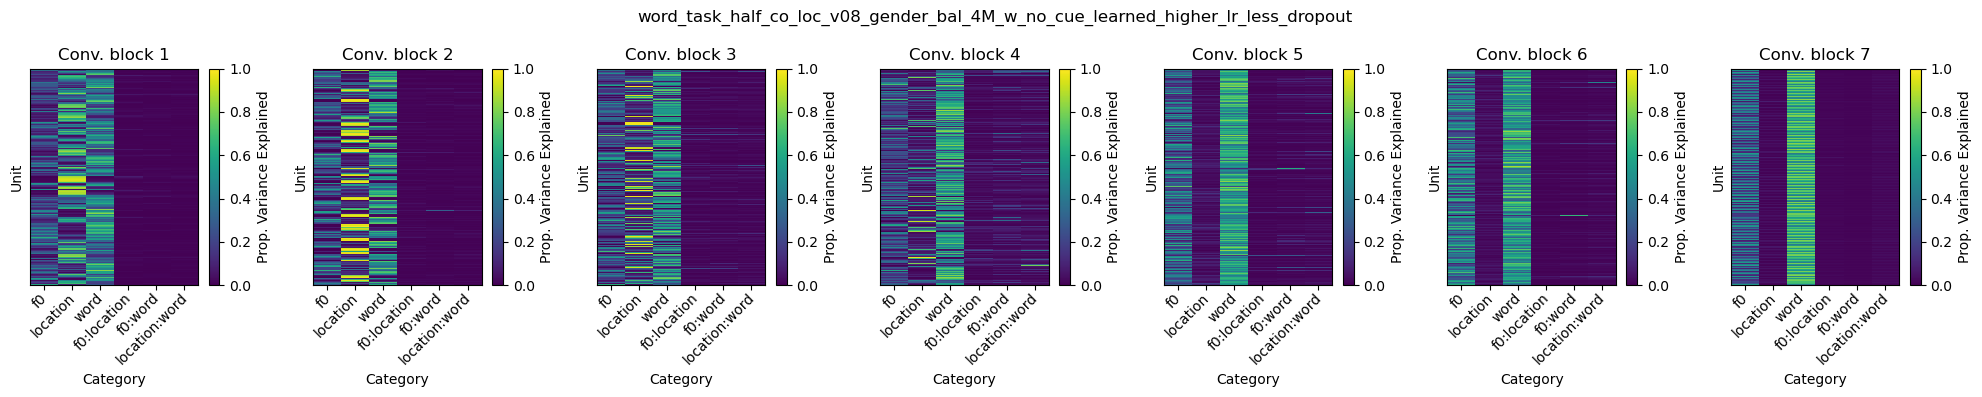

In [9]:
### Use imshow to plot the SSQ per unit
n_to_plot = len(results_dict)
fig, ax = plt.subplots(1, n_to_plot, figsize=(20, 4))

REMOVE_ZERO_UNITS=True

n_cats = len(category_labels) # will be for location, f0, interaction
for layer_ix, (layer_name, results) in enumerate(results_dict.items()):
    results_to_plot_ssq = results['prop_var_exp']
    if REMOVE_ZERO_UNITS:
        results_to_plot_ssq = results_to_plot_ssq[results_to_plot_ssq.sum(axis=1) > 0]
    n_units = results_to_plot_ssq.shape[0]
    panel = ax[layer_ix].imshow(results_to_plot_ssq, aspect='auto', cmap='viridis', vmin=0, vmax=1, interpolation='none')
    ax[layer_ix].set_xlabel('Category')
    ax[layer_ix].set_ylabel('Unit')
    ax[layer_ix].set_title(f"Conv. block {layer_ix+1}")
    ax[layer_ix].set_yticks([])
    ax[layer_ix].set_xticks(np.arange(n_cats))
    ax[layer_ix].set_xticklabels(category_labels, rotation=45, ha='right', va='center_baseline',  rotation_mode='anchor')
    # add colorbar
    cbar = plt.colorbar(panel, ax=ax[layer_ix])
    cbar.set_label('Prop. Variance Explained')

plt.suptitle(f"{model}")    
plt.tight_layout()

    # move legend outside of plot